#JPEG 구현에 사용할 이미지를 만들기 위해 필요한 함수 및 이미지

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.fftpack import dct, idct

# 환경 구축 및 이미지 로드
from google.colab import drive
drive.mount('/content/drive')

    # MSE 계산 함수
def calculate_mse(original, restored):
    return np.mean((original - restored) ** 2)

# 이미지 로드 및 변환 (RGB 이미지)
image = cv2.imread('/content/drive/My Drive/Colab Notebooks/lena.bmp', cv2.IMREAD_COLOR)
image_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV).astype(np.float32)  # 연산 전에 int32로 변환해야 overflow 발생 안함

Mounted at /content/drive


압축에 필요한 함수

In [2]:
# 8*8 크기로 분할
def split_image_into_blocks(image_yuv, block_size):
    blocks = []
    height, width, channel = image_yuv.shape
    for y in range(0, height, block_size):
        for x in range(0, width, block_size):
            block = image_yuv[y:y + block_size, x:x + block_size, :]
            blocks.append(block)

    return blocks # 리스트

# 2D DCT 적용
def apply_2d_dct(image):
    return dct(dct(image.T, norm='ortho').T, norm='ortho')

# 양자화 수행
def quantize(image, quant_table, QP):

    adjusted_quant_table = quant_table * QP

    return np.round(image / adjusted_quant_table).astype(int)

# 기존 8x8 양자화 테이블
luminance_quant_table = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

# 기존 8* Chrominance 양자화 테이블 정의
chrominance_quant_table = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])

# Zig-Zag 재배열
def zigzag(image):
    rows, cols = image.shape
    result = []

    for d in range(rows + cols - 1):
        if d % 2 == 1:  # 홀수 대각선: 아래에서 위로
            for i in range(max(0, d - cols + 1), min(d + 1, rows)):
                result.append(image[i, d - i])
        else:  # 짝수 대각선: 위에서 아래로
            for i in range(max(0, d - rows + 1), min(d + 1, cols)):
                result.append(image[d - i, i])

    return np.array(result)

# Unary 코딩
def unary_encode(zigzag_result):
    unary_encoded = []
    for value in zigzag_result:
        if value >= 0:
            unary_encoded.append('1' * value + '0')
        else:
            unary_encoded.append('1' * abs(value) + '0' + '-')  # 음수 값은 마지막에 '-' 추가
    return unary_encoded

# Y 이미지를 DCT, 양자화, Zig-Zag 재배열, Unary
def image_compress(image, quant_table, QP):

    image = apply_2d_dct(image)  # DCT 적용
    image = quantize(image, quant_table, QP)  # 양자화 수행
    zigzag_result = zigzag(image)  # Zig-Zag 재배열
    unary_result = unary_encode(zigzag_result) # 각 zigzag_result 요소를 unary 코딩

    return unary_result # 리스트 형태

복원에 필요한 함수

In [3]:
# 2D IDCT 적용 (역변환)
def apply_2d_idct(coefficients):
    return idct(idct(coefficients.T, norm='ortho').T, norm='ortho')

# 양자화 역변환
def dequantize(quantized_image, quant_table, QP):
    adjusted_quant_table = quant_table * QP

    # 양자화 역변환 수행
    return (quantized_image * adjusted_quant_table).astype(float)

# Zig-Zag 역재배열
def inverse_zigzag(arr):
    result = np.zeros((8, 8), dtype=float)
    index = 0

    for d in range(8 + 8- 1):
        if d % 2 == 1:  # 홀수 대각선: 아래에서 위로
            for i in range(max(0, d - 8 + 1), min(d + 1, 8)):
                result[i, d - i] = arr[index]
                index += 1
        else:  # 짝수 대각선: 위에서 아래로
            for i in range(max(0, d - 8 + 1), min(d + 1, 8)):
                result[d - i, i] = arr[index]
                index += 1

    return result

# Unary 디코딩
def unary_decode(compressed_image):
    decoded = []
    for code in compressed_image:
        if code.endswith('-'):
            value = -len(code[:-1].rstrip('0'))
        else:
            value = len(code.rstrip('0'))
        decoded.append(value)
    return np.array(decoded)

# 압축된 결과로부터 원본 이미지 복원
def image_decompress(compressed_image, quant_table, QP):

    zigzag_result = unary_decode(compressed_image)  # Unary 디코딩
    dezigzagged = inverse_zigzag(zigzag_result)# Zig-Zag 역재배열
    dequantized = dequantize(dezigzagged, quant_table, QP) # 양자화 역변환
    restored_image = apply_2d_idct(dequantized)   # IDCT를 통해 원래 이미지로 복원

    return restored_image

def restore_image_from_blocks(restored_image_list):

    restored_image = np.zeros((512,512,3), dtype = np.uint8)
    idx = 0
    for y in range(0, 512, 8):
        for x in range(0, 512, 8):
            restored_image[y:y + 8, x:x + 8, :] = restored_image_list[idx]
            idx += 1

    return restored_image

# JPEG 압축 및 복원 실행

1 13.029672 6.497364044189453
2 19.075972 4.732326507568359
3 25.18843 4.147502899169922
5 38.459763 3.6810379028320312
10 85.71384 3.3328399658203125
20 229.01872 3.165546417236328


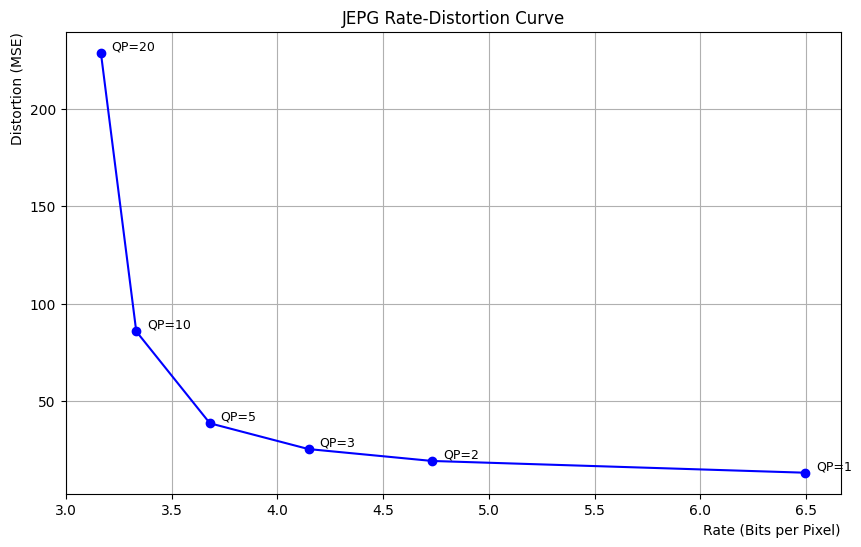

In [4]:
# 원본과 압축-복원 이미지의 distortion 및 총 비트
image_list = split_image_into_blocks(image_yuv, 8)
size = 0
QP_values = [1, 2, 3, 5, 10, 20]
rate_list = []
distortion_list = []

for qp in QP_values:
    restored_image_list = []
    size = 0

    # 각 블록에 대해 압축, 복원, 비트 수 계산 수행
    for i, image in enumerate(image_list):
        compressed_image_Y = image_compress(image[:, :, 0], luminance_quant_table, QP=qp)
        compressed_image_U = image_compress(image[:, :, 1], chrominance_quant_table, QP=qp)
        compressed_image_V = image_compress(image[:, :, 2], chrominance_quant_table, QP=qp)

        decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP=qp)
        decompressed_image_U = image_decompress(compressed_image_U, chrominance_quant_table, QP=qp)
        decompressed_image_V = image_decompress(compressed_image_V, chrominance_quant_table, QP=qp)

        final_image = np.stack((decompressed_image_Y, decompressed_image_U, decompressed_image_V), axis=2)
        restored_image_list.append(final_image)

        # 총 비트 수 계산 (압축된 데이터 크기)
        total_bits = sum(len(code) for code in compressed_image_Y) + sum(len(code) for code in compressed_image_U) + sum(len(code) for code in compressed_image_V)
        size += total_bits

    # 복원된 이미지 생성
    restored_image = restore_image_from_blocks(restored_image_list)

    # MSE 계산
    mse_value = calculate_mse(image_yuv, restored_image)
    distortion_list.append(mse_value)

    # Rate 계산 (총 비트 수 / 총 픽셀 수)
    rate = size / 262144  # 512 * 512
    rate_list.append(rate)

    print(qp, mse_value, rate)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(rate_list, distortion_list, marker='o', linestyle='-', color='b')

# 각 포인트에 QP 값 표시
for i, qp in enumerate(QP_values):
    plt.text(rate_list[i]+0.05, distortion_list[i]+0.05, f'QP={qp}', fontsize=9, ha='left', va='bottom')

plt.xlabel('Rate (Bits per Pixel)', loc = 'right')
plt.ylabel('Distortion (MSE)',loc = 'top')
plt.title('JEPG Rate-Distortion Curve')
plt.grid(True)
plt.show()